In [1]:
import pandas as pd

In [2]:
clean_urls_df = pd.read_excel('/content/Clean URLs.xlsx', header=None)
malicious_urls_df = pd.read_excel('/content/Malicious URLs.xlsx', header=None)

### Clean URLs DataFrame Head

In [3]:
display(clean_urls_df.head())

,0
0,https://www.google.com/
1,https://www.gtld-servers.net/
2,https://www.gstatic.com/
3,https://www.cloudflare.com/
4,https://www.facebook.com/


### Malicious URLs DataFrame Head

In [4]:
display(malicious_urls_df.head())

,0
0,https://365onlinegamesw.com
1,https://governorofpokerb.com
2,https://p999logingamer.com
3,https://gamespkonlinek.com
4,https://pakgameloginappl.com


In [5]:
clean_urls_df.rename(columns={0: 'url'}, inplace=True)
clean_urls_df['label'] = 0
display(clean_urls_df.head())

,url,label
0,https://www.google.com/,0
1,https://www.gtld-servers.net/,0
2,https://www.gstatic.com/,0
3,https://www.cloudflare.com/,0
4,https://www.facebook.com/,0


In [6]:
malicious_urls_df.rename(columns={0: 'url'}, inplace=True)
malicious_urls_df['label'] = 1
display(malicious_urls_df.head())

,url,label
0,https://365onlinegamesw.com,1
1,https://governorofpokerb.com,1
2,https://p999logingamer.com,1
3,https://gamespkonlinek.com,1
4,https://pakgameloginappl.com,1


In [7]:
combined_urls_df = pd.concat([clean_urls_df, malicious_urls_df], ignore_index=True)
display(combined_urls_df.head())


,url,label
0,https://www.google.com/,0
1,https://www.gtld-servers.net/,0
2,https://www.gstatic.com/,0
3,https://www.cloudflare.com/,0
4,https://www.facebook.com/,0


In [8]:
combined_urls_df = pd.concat([clean_urls_df, malicious_urls_df], ignore_index=True)
print(f"Original number of rows: {len(combined_urls_df)}")
combined_urls_df.drop_duplicates(subset=['url'], inplace=True)
print(f"Number of rows after removing duplicates: {len(combined_urls_df)}")

# Check for missing values
missing_values_count = combined_urls_df.isnull().sum()
print("\nMissing values per column:\n", missing_values_count)

# If there are missing values, decide on a strategy (e.g., drop rows, fill with placeholder)
# For now, let's assume dropping rows with any missing values if they exist, though unlikely for URL data
if missing_values_count.sum() > 0:
    combined_urls_df.dropna(inplace=True)
    print(f"Number of rows after handling missing values: {len(combined_urls_df)}")


display(combined_urls_df.head())
combined_urls_df.info()

Original number of rows: 16631
Number of rows after removing duplicates: 16421

Missing values per column:
 url      1
label    0
dtype: int64
Number of rows after handling missing values: 16420


,url,label
0,https://www.google.com/,0
1,https://www.gtld-servers.net/,0
2,https://www.gstatic.com/,0
3,https://www.cloudflare.com/,0
4,https://www.facebook.com/,0


<class 'pandas.core.frame.DataFrame'>
Index: 16420 entries, 0 to 16628
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   url     16420 non-null  object
 1   label   16420 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 384.8+ KB


In [9]:
combined_urls_df = combined_urls_df.sample(frac=1, random_state=42).reset_index(drop=True)
display(combined_urls_df.head())
print(f"Shape of shuffled DataFrame: {combined_urls_df.shape}")

,url,label
0,https://tartarcusp.com/bzrawe/,1
1,https://www.netnod.se/,0
2,https://dl.dropboxusercontent.com/scl/fi/lc7j7...,1
3,aefofhhfouahugr.ws,1
4,https://aazsbsgya565vlu2c6bzy6yfiebkcbtvvcytvo...,1


Shape of shuffled DataFrame: (16420, 2)


In [10]:
final_urls = 'combined_urls.xlsx'
combined_urls_df.to_excel(final_urls, index=False)
print(f"DataFrame successfully saved to '{final_urls}'")


DataFrame successfully saved to 'combined_urls.xlsx'


In [11]:
# Load the combined_urls.xlsx file into a new DataFrame
loaded_combined_urls_df = pd.read_excel('combined_urls.xlsx')

# Display the first 10 rows of the loaded DataFrame
display(loaded_combined_urls_df.head(10))

,url,label
0,https://tartarcusp.com/bzrawe/,1
1,https://www.netnod.se/,0
2,https://dl.dropboxusercontent.com/scl/fi/lc7j7...,1
3,aefofhhfouahugr.ws,1
4,https://aazsbsgya565vlu2c6bzy6yfiebkcbtvvcytvo...,1
5,https://www.argentina.gob.ar/,0
6,https://www.queniusz.com/,0
7,https://www.steamserver.net/,0
8,https://www.ucsf.edu/,0
9,http://168.100.8.42/micro[.]exe,1


In [12]:
pip install tensorflow

# **Tokenization and Sequence**

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

# 1. Tokenizer initialize karein character-level par
# <OOV> ka matlab hai 'Out Of Vocabulary' - agar koi naya character test data mein aaye toh model crash na kare
tokenizer = Tokenizer(char_level=True, oov_token='<OOV>')

# 2. Tokenizer ko poore dataset ke URLs par fit karein (Dictionary/Vocabulary banana)
tokenizer.fit_on_texts(loaded_combined_urls_df['url'])

# 3. Raw text strings ko numeric sequences mein convert karein
sequences = tokenizer.texts_to_sequences(loaded_combined_urls_df['url'])

# 4. Tasalli ke liye output print kar ke check karein
print("Total Unique Characters (Vocabulary Size):", len(tokenizer.word_index))
print("\nCharacter Dictionary Mapping (Pehle 10):")
print(dict(list(tokenizer.word_index.items())[:10]))

print("\n--- Testing on Row 0 ---")
print("Original URL String:", loaded_combined_urls_df['url'][0])
print("Converted Numeric Sequence:", sequences[0])
print("Converted Numeric Sequence:", sequences[1])

Total Unique Characters (Vocabulary Size): 85

Character Dictionary Mapping (Pehle 10):
{'<OOV>': 1, '/': 2, 't': 3, 'w': 4, '.': 5, 's': 6, 'p': 7, 'o': 8, 'h': 9, 'e': 10}

--- Testing on Row 0 ---
Original URL String: https://tartarcusp.com/bzrawe/
Converted Numeric Sequence: [9, 3, 3, 7, 6, 13, 2, 2, 3, 12, 17, 3, 12, 17, 11, 20, 6, 7, 5, 11, 8, 14, 2, 22, 38, 17, 12, 4, 10, 2]
Converted Numeric Sequence: [9, 3, 3, 7, 6, 13, 2, 2, 4, 4, 4, 5, 16, 10, 3, 16, 8, 19, 5, 6, 10, 2]


to find max and min length

In [14]:
# 1. Har URL ki character length calculate karein
url_lengths = loaded_combined_urls_df['url'].astype(str).str.len()

# 2. Stats print karein
print("--- URL Length Statistics ---")
print("Minimum URL Length:", url_lengths.min())
print("Maximum URL Length:", url_lengths.max())
print("Average URL Length:", round(url_lengths.mean(), 2))

# 3. 95th aur 99th percentile check karein (taake extreme outliers ka pata chale)
print("95% of URLs are shorter than:", url_lengths.quantile(0.95))
print("99% of URLs are shorter than:", url_lengths.quantile(0.99))

--- URL Length Statistics ---
Minimum URL Length: 3
Maximum URL Length: 393
Average URL Length: 29.26
95% of URLs are shorter than: 55.0
99% of URLs are shorter than: 86.0


**Padding**

In [15]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Dataset ke 99th percentile ke mutabiq max length set karein
MAX_LEN = 86

# 2. Sequences ko pad aur truncate karein
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# 3. Shape aur sample check karein
print("Input Data (X) Shape:", X.shape)
print("\n--- Example: Padded Row 0 (First 20 tokens) ---")
print(X[0][:20])
print("\n--- Example: Padded Row 0 (Last 20 tokens to check zeros) ---")
print(X[0][-20:])

Input Data (X) Shape: (16420, 86)

--- Example: Padded Row 0 (First 20 tokens) ---
[ 9  3  3  7  6 13  2  2  3 12 17  3 12 17 11 20  6  7  5 11]

--- Example: Padded Row 0 (Last 20 tokens to check zeros) ---
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [31]:
import json

# Tokenizer configuration to JSON
tokenizer_json = tokenizer.to_json()

# Save the JSON string to a file
with open('tokenizer_config.json', 'w', encoding='utf-8') as f:
    f.write(json.dumps(tokenizer_json, ensure_ascii=False))

print("Tokenizer configuration saved to 'tokenizer_config.json'")

Tokenizer configuration saved to 'tokenizer_config.json'


Now, along with `phishing_1dcnn_model.keras`, you would also take `tokenizer_config.json` and the `MAX_LEN` value (which is 86) to your VS Code project. You would then load them as follows:

**2. Loading the Tokenizer in a new environment (e.g., VS Code):**

I'll generate another cell to demonstrate how to load the tokenizer from the saved file.

In [32]:
from tensorflow.keras.preprocessing.text import tokenizer_from_json

# Load the JSON string from the file
with open('tokenizer_config.json', 'r', encoding='utf-8') as f:
    loaded_tokenizer_json = json.load(f)

# Recreate the Tokenizer object from the JSON string
loaded_tokenizer = tokenizer_from_json(loaded_tokenizer_json)

print("Tokenizer loaded successfully from 'tokenizer_config.json'")
print("Example: First 10 words in loaded tokenizer's word_index:", dict(list(loaded_tokenizer.word_index.items())[:10]))

# You would also use the same MAX_LEN value
# loaded_MAX_LEN = 86 # or load it from a config if stored separately


Tokenizer loaded successfully from 'tokenizer_config.json'
Example: First 10 words in loaded tokenizer's word_index: {'<OOV>': 1, '/': 2, 't': 3, 'w': 4, '.': 5, 's': 6, 'p': 7, 'o': 8, 'h': 9, 'e': 10}


By doing this, you ensure that any new URLs are tokenized and padded using the exact same vocabulary and length constraints that your model was trained on, guaranteeing consistent preprocessing and accurate predictions in your deployment environment.

# **Embedding and 1D CNN Architecture**

In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Input(shape=(86,)),
    Embedding(input_dim=86, output_dim=32),
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    # Option 1: Replace GlobalMaxPool with AveragePool — less aggressive
    GlobalAveragePooling1D(),
    # Option 2: Or add Dropout before the Dense layer
    Dropout(0.3),
    Dense(units=1, activation='sigmoid')
])

# 7. Model ka Poora Structure Print Karein
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 86, 32)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 86, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,025 (35.25 KB)

 Trainable params: 9,025 (35.25 KB)

 Non-trainable params: 0 (0.00 B)

Here's a concise summary of the 1D CNN model architecture:

This model uses character-level embeddings for URL classification. It consists of:

*   **Embedding Layer:** Converts each of the 86 characters in a URL into a 32-dimensional vector. (2,720 parameters)
*   **Conv1D Layer:** Applies 64 convolutional filters (kernel size 3) to detect local patterns in the character embeddings. (6,208 parameters)
*   **Global Max Pooling:** Selects the most important feature from each of the 64 filters. (0 parameters)
*   **Dense Layer:** A final output layer with sigmoid activation to classify the URL as safe or phishing. (65 parameters)

**Total Trainable Parameters:** The model has a total of **8,993 parameters** that will be adjusted during training to learn to distinguish between safe and phishing URLs.

# **Compilation**
it means to tell the model how to count loss function and how to update the weights the Optimizer.

In [17]:
# Model ko compile karna (Rules set karna)
model.compile(
    optimizer='adam',                # Optimizer jo weights ko halka sa nudge/adjust karega
    loss='binary_crossentropy',     # Loss function jo binary (0 ya 1) ke liye best hai
    metrics=['accuracy']            # Training ke dauran hume accuracy track karni hai
)

print("Model successfully compiled!")

Model successfully compiled!


In [21]:
from sklearn.model_selection import train_test_split

# Define y from the 'label' column of your combined DataFrame
y = loaded_combined_urls_df['label']

# Pura data split karein: 80% Training aur 20% Pure Testing ke liye
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (13136, 86)
Testing data size: (3284, 86)


# **Now Training**

### Implementing Early Stopping

To combat the overfitting observed (where validation loss increased while training loss decreased), we will implement an `EarlyStopping` callback. This callback will monitor the `val_loss` and stop training if it doesn't improve for a specified number of epochs (patience).

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the EarlyStopping callback
# It will monitor 'val_loss'
# 'patience=2' means it will wait for 2 epochs after the validation loss stops improving before stopping
# 'restore_best_weights=True' will ensure the model reverts to the best weights found during training
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print("EarlyStopping callback defined.")

EarlyStopping callback defined.


Now, let's retrain the model with this `EarlyStopping` callback. This will replace the previous training run.

In [23]:
# 1. Target labels (y) ko DataFrame se extract karein


# 2. Asli Training Module (Data feeding)
# Yahan hum model ko batayenge ke X (sequences) aur y (labels) ko kaise use karna hai
history = model.fit(
    X_train,                      # Aapka preprocessed input data (16420 rows, 86 columns)
    y_train,                      # Aapke safe (0) aur phishing (1) wale labels
    epochs=20,               # Poore dataset par model 20 baar chakkar lagayega
    batch_size=64,          # Ek waqt mein 64 URLs andar jayenge (Yahan None ki jagah 64 set hoga!)
    validation_split=0.2,    # 20% data validation/testing ke liye alag lock kar do
    callbacks=[early_stopping]
)

Epoch 1/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.8076 - loss: 0.4171 - val_accuracy: 0.9775 - val_loss: 0.1193
Epoch 2/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9827 - loss: 0.0866 - val_accuracy: 0.9852 - val_loss: 0.0611
Epoch 3/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9848 - loss: 0.0654 - val_accuracy: 0.9871 - val_loss: 0.0505
Epoch 4/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9860 - loss: 0.0610 - val_accuracy: 0.9886 - val_loss: 0.0450
Epoch 5/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9872 - loss: 0.0539 - val_accuracy: 0.9897 - val_loss: 0.0410
Epoch 6/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9872 - loss: 0.0523 - val_accuracy: 0.9893 - val_loss: 0.0407
Epoch 7/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9884 - loss: 0.0497 - val_accuracy: 0.9897 - val_loss: 0.0383
Epoch 8/20
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9888 - loss: 0.0465 - val_accu

In [25]:
# Unseen Test Dataset par model ka asli board exam
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n--- 🚨 FINAL BOARD EXAM RESULTS 🚨 ---")
print(f"Test Data Loss: {test_loss:.6f}")
print(f"Test Data Accuracy: {test_accuracy * 100:.2f}%")

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0294

--- 🚨 FINAL BOARD EXAM RESULTS 🚨 ---
Test Data Loss: 0.029415
Test Data Accuracy: 99.21%


In [26]:
# Model ko Colab ki temporary hard drive par save karne ke liye
model.save('phishing_1dcnn_model.keras')
print("Model successfully saved as 'phishing_1dcnn_model.keras'!")

Model successfully saved as 'phishing_1dcnn_model.keras'!


### 📈 Visualizing Training History

Let's plot the training and validation accuracy and loss over the epochs to see how the model learned and to identify any signs of overfitting.

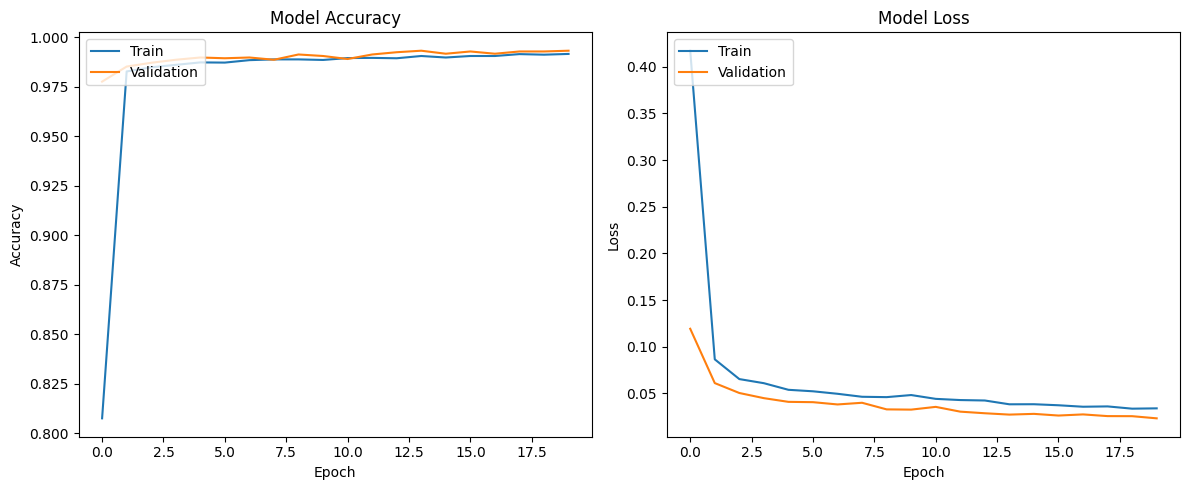

In [27]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

### 📊 Detailed Classification Report and Confusion Matrix

To get a more granular view of the model's performance, especially regarding false positives and false negatives, we'll generate a classification report and a confusion matrix.

103/103 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
### Classification Report ###

              precision    recall  f1-score   support

       Clean       0.99      1.00      0.99      2000
    Phishing       1.00      0.98      0.99      1284

    accuracy                           0.99      3284
   macro avg       0.99      0.99      0.99      3284
weighted avg       0.99      0.99      0.99      3284



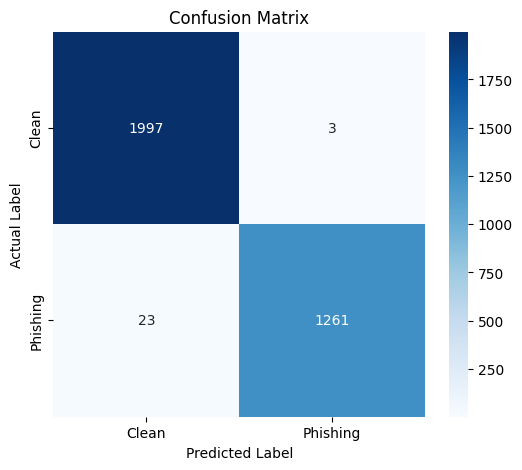

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions on the test set
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Classification Report
print("### Classification Report ###\n")
print(classification_report(y_test, y_pred, target_names=['Clean', 'Phishing']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clean', 'Phishing'], yticklabels=['Clean', 'Phishing'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

This detailed evaluation should give you a comprehensive understanding of your 1D CNN's performance, highlighting its strengths and any areas for potential improvement!

## **Testing the model to see if it holds up to the real world**

In [30]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# ── 1. Load saved model ──────────────────────────────────────────────────────
model = load_model('phishing_1dcnn_model.keras')

# ── 2. Rebuild tokenizer from your combined dataset ──────────────────────────
#    Must match exactly what was used during training
tokenizer = Tokenizer(char_level=True, oov_token='<OOV>')
tokenizer.fit_on_texts(loaded_combined_urls_df['url'])   # same df as training
MAX_LEN = 86

# ── 3. Test URLs ─────────────────────────────────────────────────────────────
test_cases = [
    # (url, expected_label, description)

    # --- Legitimate ---
    ("https://www.hec.gov.pk/",                                    0, "HEC Pakistan"),
    ("https://www.python.org/downloads/release/python-3120/",      0, "Python downloads"),
    ("https://huggingface.co/models",                              0, "HuggingFace"),
    ("https://stackoverflow.com/questions/tagged/tensorflow",      0, "Stack Overflow"),
    ("https://www.dawn.com/news/1900000",                          0, "Dawn News"),
    ("https://portal.azure.com/#home",                             0, "Azure portal"),
    ("https://colab.research.google.com/drive/1abc123",            0, "Google Colab"),
    ("https://www.kaggle.com/competitions",                        0, "Kaggle"),

    # --- Typosquatting ---
    ("http://paypa1.com/signin/verify?token=abc123",               1, "paypal typo (1→l)"),
    ("http://g00gle-security.com/account/confirm",                 1, "google typo (oo→00)"),
    ("http://arnazon-prime.com/billing/update",                    1, "amazon typo"),
    ("http://faceb00k-login.tk/recover/password",                  1, "facebook typo + .tk"),

    # --- IP-based ---
    ("http://192.168.1.1/admin/login.php",                         1, "private IP"),
    ("http://45.33.32.156/secure/banking/update",                  1, "raw public IP"),

    # --- Brand-in-subdomain + junk TLD ---
    ("http://netflix.com.account-verify.xyz/login",                1, "netflix brand in subdomain"),
    ("http://paypal.com.secure-update.ru/verify",                  1, "paypal brand in subdomain"),
    ("http://apple.com-id-locked.gq/recover",                      1, "apple brand in domain"),

    # --- Edge cases ---
    ("http://bit.ly/3xKq9mP",                                      None, "URL shortener (ambiguous)"),
    ("https://docs.google.com/forms/d/e/1FAIpQLSd8x9f/viewform",  None, "Google Forms (legit but phishing-used)"),
]

# ── 4. Preprocess & predict ───────────────────────────────────────────────────
urls       = [tc[0] for tc in test_cases]
sequences  = tokenizer.texts_to_sequences(urls)
X_test_rw  = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

proba = model.predict(X_test_rw, verbose=0).flatten()
preds = (proba > 0.5).astype(int)

# ── 5. Print results ──────────────────────────────────────────────────────────
print(f"\n{'URL':<55} {'Conf':>6}  {'Pred':>8}  {'Expected':>8}  {'Result':>6}")
print("─" * 95)

correct = 0
total_labeled = 0

for (url, expected, desc), prob, pred in zip(test_cases, proba, preds):
    label     = "PHISHING" if pred == 1 else "SAFE"
    conf_str  = f"{prob:.3f}"

    if expected is None:
        result_str = "—  edge"
    else:
        total_labeled += 1
        if pred == expected:
            correct += 1
            result_str = "✓"
        else:
            result_str = "✗  ← WRONG"

    exp_str = "phishing" if expected == 1 else ("safe" if expected == 0 else "?")
    print(f"{url:<55} {conf_str:>6}  {label:>8}  {exp_str:>8}  {result_str}")

print("─" * 95)
print(f"\nLabeled test accuracy: {correct}/{total_labeled} ({100*correct/total_labeled:.1f}%)")
print(f"(Edge cases excluded from score — observe their confidence manually)\n")


URL                                                       Conf      Pred  Expected  Result
───────────────────────────────────────────────────────────────────────────────────────────────
https://www.hec.gov.pk/                                  0.004      SAFE      safe  ✓
https://www.python.org/downloads/release/python-3120/    0.999  PHISHING      safe  ✗  ← WRONG
https://huggingface.co/models                            1.000  PHISHING      safe  ✗  ← WRONG
https://stackoverflow.com/questions/tagged/tensorflow    1.000  PHISHING      safe  ✗  ← WRONG
https://www.dawn.com/news/1900000                        0.937  PHISHING      safe  ✗  ← WRONG
https://portal.azure.com/#home                           1.000  PHISHING      safe  ✗  ← WRONG
https://colab.research.google.com/drive/1abc123          1.000  PHISHING      safe  ✗  ← WRONG
https://www.kaggle.com/competitions                      0.500      SAFE      safe  ✓
http://paypa1.com/signin/verify?token=abc123             1.000  PHISHI